# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Mahati Vedula

**Date:** 09/09/2026

(28221, 10) 

ID                            int64
OPEID                         int64
Institution Name                str
City                            str
State                           str
Foreign Gift Received Date    int64
Foreign Gift Amount           int64
Gift Type                       str
Country of Giftor               str
Giftor Name                     str
dtype: object 

    ID   OPEID               Institution Name          City State  Foreign Gift Received Date  Foreign Gift Amount      Gift Type Country of Giftor                          Giftor Name
0    1  102000  Jacksonville State University  Jacksonville    AL                       43738               250000  Monetary Gift             CHINA                                  NaN
1    2  104700                Troy University          Troy    AL                       43592               463657       Contract             CHINA     Confucius Institute Headquarters
2    3  105100          University of Alabama    Tuscal

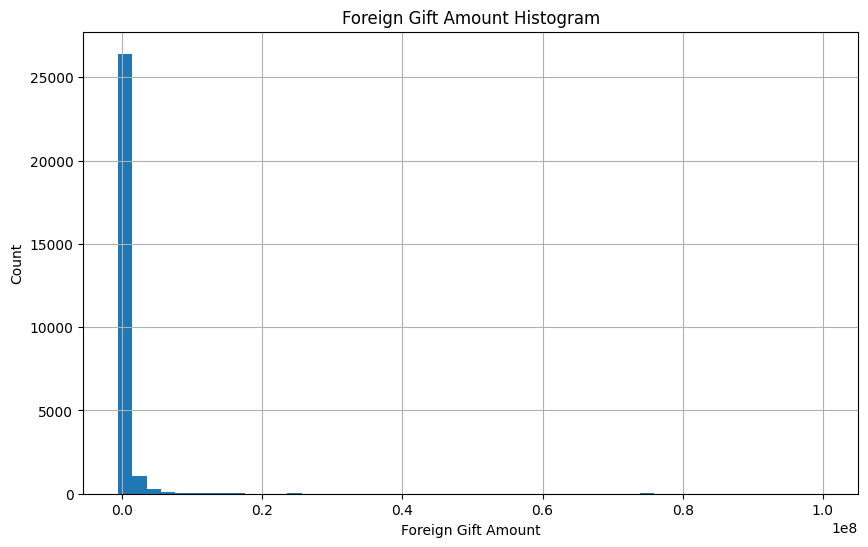

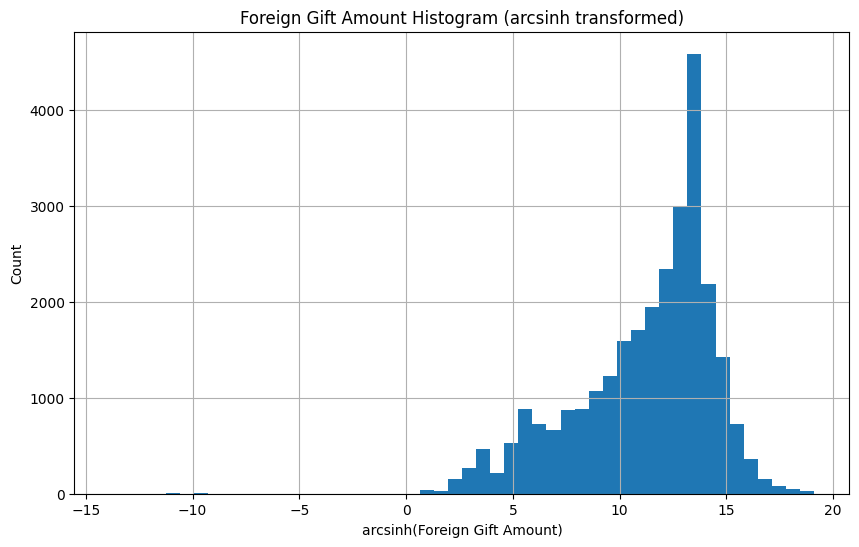

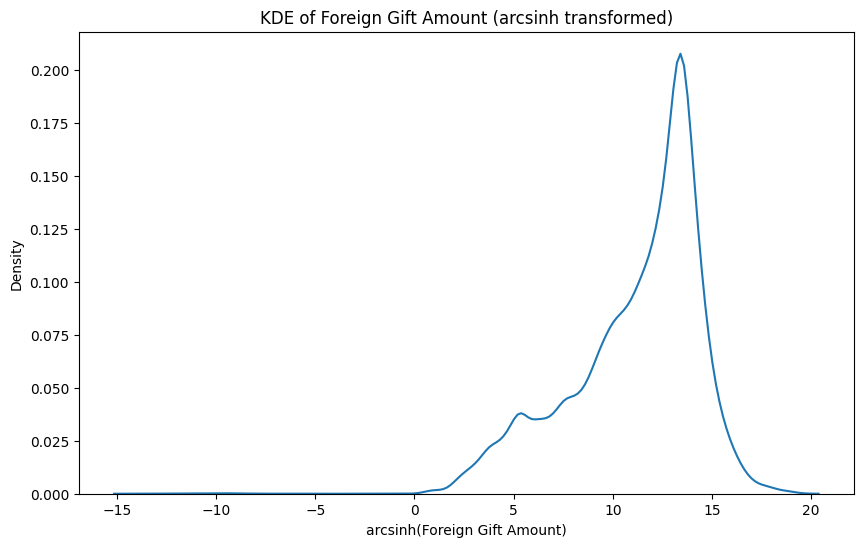

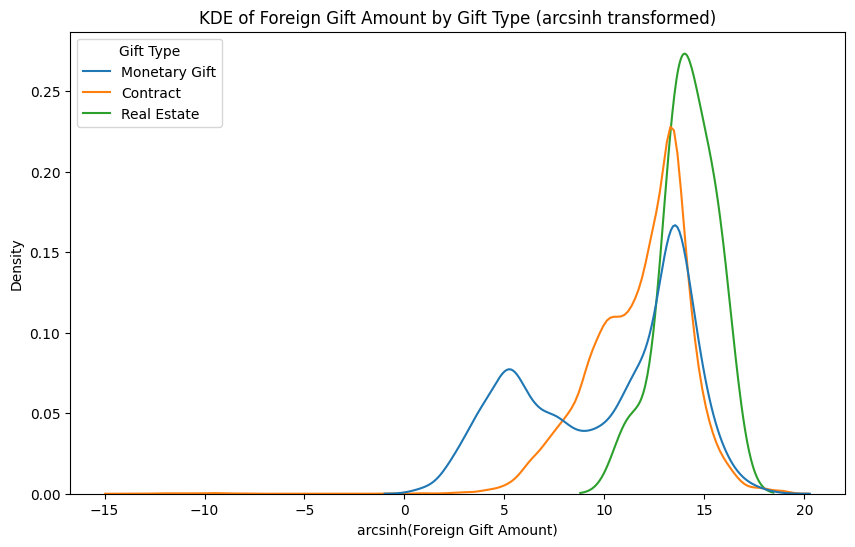

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: ID, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


In [7]:
# PART 1: Completed on paper and uploaded to GitHub repo

# PART 2

# Import libraries and load the data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('data/ForeignGifts_edu.csv', low_memory=False)

# Explore data
print(df.shape, '\n')
print(df.dtypes, '\n')
print(df.head(n=15).to_string(), '\n')
print(df.describe().to_string(), '\n')

# Foreign gift amount histogram
fig, ax = plt.subplots(figsize=(10, 6))
df['Foreign Gift Amount'].hist(bins=50, ax=ax)
ax.set_title('Foreign Gift Amount Histogram')
ax.set_xlabel('Foreign Gift Amount')
ax.set_ylabel('Count')
plt.show()
# Revised histogram using arcsinh transformation
df["gift_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
fig, ax = plt.subplots(figsize=(10, 6))
df['gift_arcsinh'].hist(bins=50, ax=ax)
ax.set_title('Foreign Gift Amount Histogram (arcsinh transformed)')
ax.set_xlabel('arcsinh(Foreign Gift Amount)')
ax.set_ylabel('Count')
plt.show()

# Gift type value counts table
df['Gift Type'].value_counts()
df['Gift Type'].value_counts(normalize=True)

# Kernel density plots of gift amount
fig,ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df, x = 'gift_arcsinh', ax=ax)
ax.set_title('KDE of Foreign Gift Amount (arcsinh transformed)')
ax.set_xlabel('arcsinh(Foreign Gift Amount)')
ax.set_ylabel('Density')
plt.show()
# KDE grouped by gift type
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df, x='gift_arcsinh', hue='Gift Type', common_norm=False, ax=ax)
ax.set_title('KDE of Foreign Gift Amount by Gift Type (arcsinh transformed)')
ax.set_xlabel('arcsinh(Foreign Gift Amount)')
ax.set_ylabel('Density')
plt.show()

# Top 15 countries by number of gifts and value of gifts
print(df.groupby('Country of Giftor')['ID'].count().sort_values(ascending=False).head(15))
print(df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15))

### Analysis
1. Dataset loaded: shape, datatypes, and summary statistics explored (see output for details).
2. After creating a regular historgram, we can see that the data is extremely right-skewed with a long thin tail stretching out to $100M. A few massive gift amounts (mean $588K vs. median $94.6K) compress almost all the data into a single bar, making the  histogram unreadable. After doing an arcsinh transformation, however, we can clearly see the shape. The data is still left-skewed but now roughly bell-shaped and centered around 12–13 with most gift amounts in the low hundred-thousands.
3. 61.2% of gifts are contracts, 38.8% are monetary donations, and 0.04% are real estate.
4. The overall distribution (post-arcsinh) is unimodal and roughly bell-shaped. However, conditioning on gift type reveals patterns the pooled KDE hides: monetary gifts are bimodal, with a large concentration of smaller individual donations as well as a separate cluster of large institutional gifts overlapping the contract peak. Additionally, real estate gifts sit furthest to the right, likely because property deals are large-dollar transactions. Gift size and gift type are related. Monetary gifts specifically contain two very different populations (small personal gifts vs. large organizational ones) that a single distribution masks.
5. The largest country in terms of the number of donations is England (see output for all of the top 15).
6. The largest country in terms of the total dollar value of donations is Qatar (see output for all of the top 15).


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 8e2ac83819c1fbb66954c69c081d0f96b6913ddf
- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. Based on the rubric, what are some ways I can improve my solution? (code pasted)
2. Give these changes in a numbered list, and focus on whats necessary vs nice to have

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Add the missing giftor's analysis of most money provided in total
2. Fix the Gift type value_counts cell to ensure output is displayed (print)

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Because I did not explain which giftors provided the most as in-depth as I could have |
| 2 | Accept | Because though my code exists, I need to ensure it shows up in the printed output |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

(28221, 10) 

ID                            int64
OPEID                         int64
Institution Name                str
City                            str
State                           str
Foreign Gift Received Date    int64
Foreign Gift Amount           int64
Gift Type                       str
Country of Giftor               str
Giftor Name                     str
dtype: object 

    ID   OPEID               Institution Name          City State  Foreign Gift Received Date  Foreign Gift Amount      Gift Type Country of Giftor                          Giftor Name
0    1  102000  Jacksonville State University  Jacksonville    AL                       43738               250000  Monetary Gift             CHINA                                  NaN
1    2  104700                Troy University          Troy    AL                       43592               463657       Contract             CHINA     Confucius Institute Headquarters
2    3  105100          University of Alabama    Tuscal

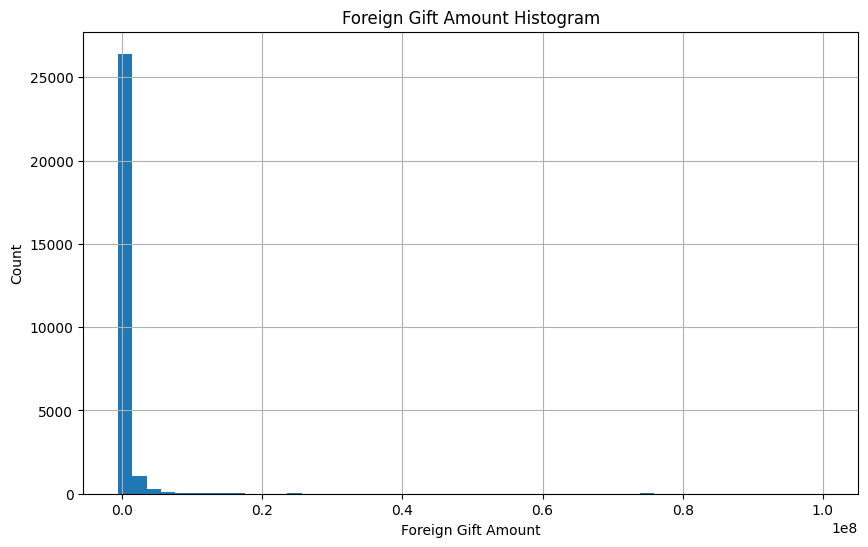

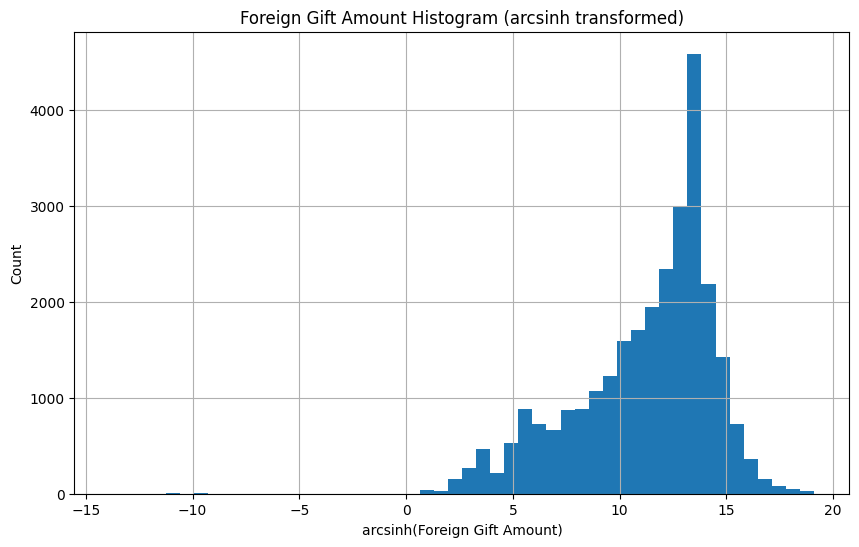

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


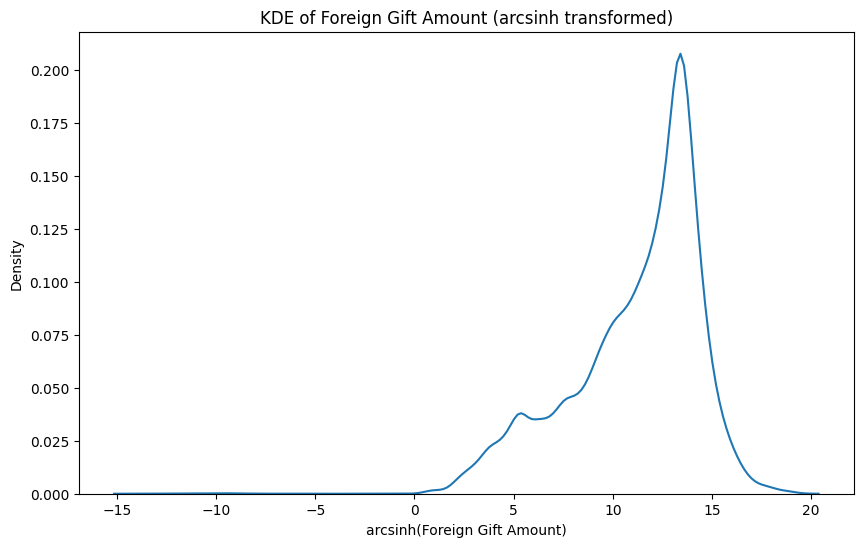

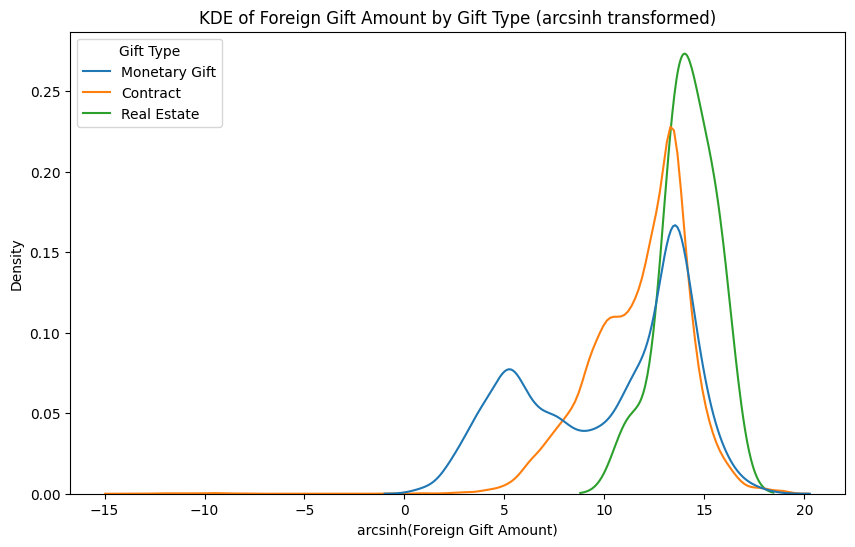

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: ID, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64
Giftor Name
Qata

In [8]:
# PART 1: Completed on paper and uploaded to GitHub repo

# PART 2

# Import libraries and load the data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('data/ForeignGifts_edu.csv', low_memory=False)

# Explore data
print(df.shape, '\n')
print(df.dtypes, '\n')
print(df.head(n=15).to_string(), '\n')
print(df.describe().to_string(), '\n')

# Foreign gift amount histogram
fig, ax = plt.subplots(figsize=(10, 6))
df['Foreign Gift Amount'].hist(bins=50, ax=ax)
ax.set_title('Foreign Gift Amount Histogram')
ax.set_xlabel('Foreign Gift Amount')
ax.set_ylabel('Count')
plt.show()
# Revised histogram using arcsinh transformation
df["gift_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
fig, ax = plt.subplots(figsize=(10, 6))
df['gift_arcsinh'].hist(bins=50, ax=ax)
ax.set_title('Foreign Gift Amount Histogram (arcsinh transformed)')
ax.set_xlabel('arcsinh(Foreign Gift Amount)')
ax.set_ylabel('Count')
plt.show()

# Gift type value counts table
print(df['Gift Type'].value_counts())
print(df['Gift Type'].value_counts(normalize=True))

# Kernel density plots of gift amount
fig,ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df, x = 'gift_arcsinh', ax=ax)
ax.set_title('KDE of Foreign Gift Amount (arcsinh transformed)')
ax.set_xlabel('arcsinh(Foreign Gift Amount)')
ax.set_ylabel('Density')
plt.show()
# KDE grouped by gift type
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df, x='gift_arcsinh', hue='Gift Type', common_norm=False, ax=ax)
ax.set_title('KDE of Foreign Gift Amount by Gift Type (arcsinh transformed)')
ax.set_xlabel('arcsinh(Foreign Gift Amount)')
ax.set_ylabel('Density')
plt.show()

# Top 15 countries by number of gifts and value of gifts
print(df.groupby('Country of Giftor')['ID'].count().sort_values(ascending=False).head(15))
print(df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15))

# Top 15 giftors by amount gifted
print(df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15))

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

For this assignment, I used AI to check over my code and ensure that I met all rubric requirements. For example, the AI agent noticed that I completely missed one of the questions I had to answer. It also suggested an improvement to my code to make sure all the output was being printed, since I had two lines that were being masked (they were not explicit print statements and not the last lines in the notebook cell). Since the AI had the rubric, it had the context of the assignment and did not make mistakes; providing the right context for the prompy helps circumvent AI limitations. To verify output, I also read through the AI suggestions and asked it to focus on necessary changes in the follow-up prompt so that I could make impactful and high-quality improvements to my submission. Lastly, I did not use the AI to revise my written explanations. However, I will consider this use case for the next assignment, as the AI might find patterns I missed, improve my communication, or identify a lack-of-depth or poor quality responses.